In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = X.copy()
df['income'] = y 
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [20]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Occupation and work-class are not necessary for bias detection but native-country may be

In [15]:
df[df['native-country'].isnull()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32580,40,Private,85019,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,45,NaN,>50K.
32626,41,Private,109912,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,0,0,40,NaN,<=50K.
32644,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,NaN,>50K.
32749,34,State-gov,513100,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,0,0,40,NaN,<=50K.
32814,42,Federal-gov,177937,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40,NaN,<=50K.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48245,46,Private,31411,11th,7,Married-civ-spouse,Other-service,Wife,White,Female,0,0,40,NaN,<=50K.
48272,24,Private,127159,Some-college,10,Never-married,Other-service,Other-relative,White,Female,0,0,24,NaN,<=50K.
48604,24,State-gov,161783,Bachelors,13,Never-married,Transport-moving,Not-in-family,Black,Male,0,0,40,NaN,<=50K.
48651,34,Private,143776,Masters,14,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,45,NaN,>50K.


In [19]:
df['workclass'].fillna('Unknown', inplace=True)
df['occupation'].fillna('Unknown', inplace=True)
df['native-country'].fillna('Unknown', inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Univariate Analysis

In [24]:
df['income'].value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Period at the end creates inconsistentcies in result

In [46]:
df['income'] = df['income'].str.replace('.', '', regex=False)
df['income'].value_counts()


income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [57]:
age = df['age']
print(age.describe())
#Finding interquartile Range
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3-Q1

print("\n" + "="*30 + "\n") # separator for clarity

print(f'IQR:{IQR}')
#Finding outliers 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_lower = df[(age< lower_bound)]
outliers_higher =  df[(age > upper_bound)]

print(f"Lower bound: {lower_bound:.2f}")
print(f"Number of lower outliers: {len(outliers_lower)}")
print(outliers_lower) 

print("\n" + "="*30 + "\n") 

print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of higher outliers: {len(outliers_higher)}")
print(outliers_higher)


count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


IQR:20.0
Lower bound: -2.00
Number of lower outliers: 0
Empty DataFrame
Columns: [age, workclass, fnlwgt, education, education-num, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country, income]
Index: []


Upper bound: 78.00
Number of higher outliers: 216
       age         workclass  fnlwgt     education  education-num  \
74      79           Private  124744  Some-college             10   
222     90           Private   51744       HS-grad              9   
430     80                 ?  107762       HS-grad              9   
918     81  Self-emp-not-inc  136063       HS-grad              9   
1040    90           Private  137018       HS-grad              9   
...    ...               ...     ...           ...            ...  

--- Descriptive Statistics for hours-per-week ---
count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


Lower Bound for Outliers: 32.50
Number of lower outliers found: 8286


Upper Bound for Outliers: 52.50
Number of higher outliers found: 5210


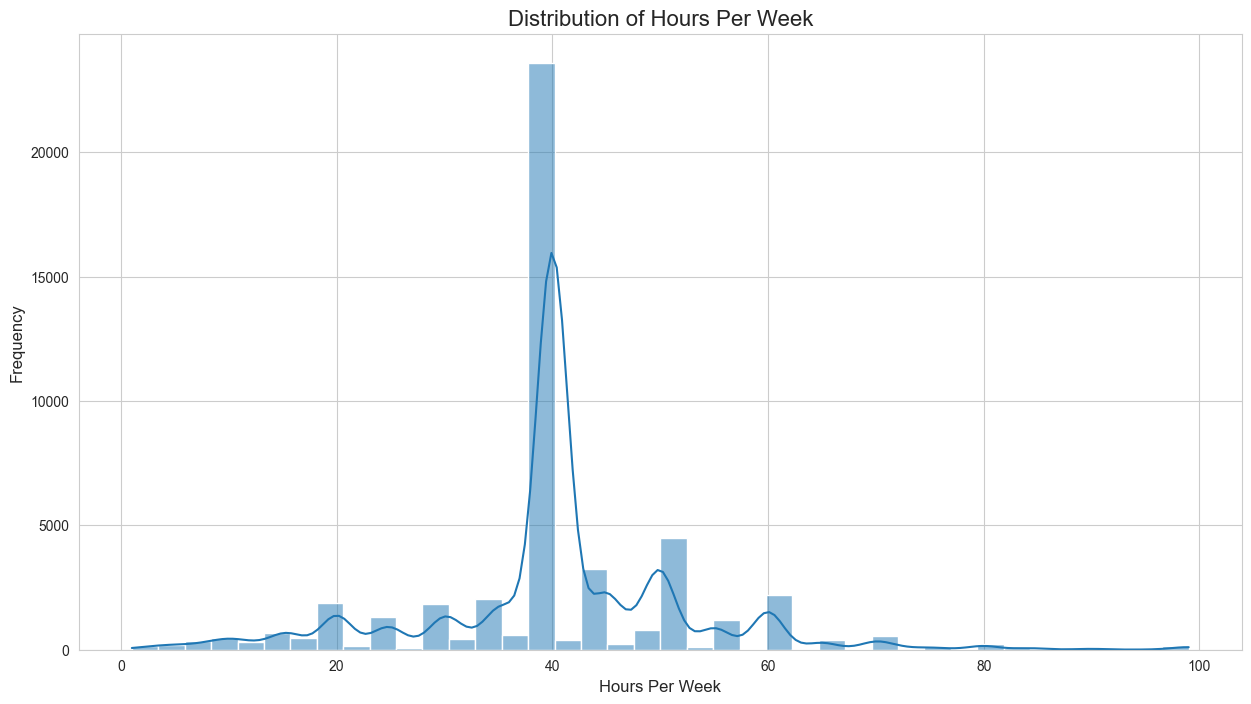

hours-per-week
99    137
98     14
97      2
96      9
95      2
94      1
92      3
91      3
90     42
89      3
Name: count, dtype: int64


In [ ]:
hours_per_week = df['hours-per-week']
print("--- Descriptive Statistics for hours-per-week ---")
print(hours_per_week.describe())
print("\n" + "="*30 + "\n")


#Calculate the Interquartile Range
Q1 = hours_per_week.quantile(0.25)
Q3 = hours_per_week.quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Find the outlier rows
outliers_lower = df[hours_per_week < lower_bound]
outliers_higher = df[hours_per_week > upper_bound]

print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Number of lower outliers found: {len(outliers_lower)}")


print("\n" + "="*30 + "\n") 

print(f"Upper Bound for Outliers: {upper_bound:.2f}")
print(f"Number of higher outliers found: {len(outliers_higher)}")

#Plotting a histogram for better understanding of the data 
sns.set_style("whitegrid")

# Create a figure to draw the plot on
plt.figure(figsize=(15, 8))

# Generate the histogram for the 'hours-per-week' column
sns.histplot(hours_per_week, bins=40, kde=True)

plt.title('Distribution of Hours Per Week', fontsize=16)
plt.xlabel('Hours Per Week', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

print(hours_per_week.value_counts().sort_index(ascending=False).head(10))  # Top 10 most extreme values





Adding a new group (labor_effort_group) in order to categorise data and view extremes with suspicion but not dismiss

In [ ]:
bins = [0, lower_bound, upper_bound, hours_per_week.max()]
labels = ['low', 'normal', 'high']

# Create the new column
df['labor_effort_group'] = pd.cut(hours_per_week, bins=bins, labels=labels, right=True)

# Verify the result by checking the value counts of the new column
print(df['labor_effort_group'].value_counts())
print(df.groupby('labor_effort_group')['hour-per-week'].describe())


labor_effort_group
normal    35346
low        8286
high       5210
Name: count, dtype: int64
                      count       mean       std   min   25%   50%   75%   max
labor_effort_group                                                            
low                  8286.0  21.063601  7.758745   1.0  15.0  20.0  30.0  32.0
normal              35346.0  41.563939  4.019833  33.0  40.0  40.0  42.0  52.0
high                 5210.0  63.466027  9.910780  53.0  57.0  60.0  65.0  99.0


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\4080205390.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('labor_effort_group')['hours-per-week'].describe())


In [85]:
print(pd.crosstab(df['sex'], df['labor_effort_group'], normalize='index'))

print("\n")

print(pd.crosstab(df['race'], df['labor_effort_group'], normalize='index'))



labor_effort_group       low    normal      high
sex                                             
Female              0.269331  0.680336  0.050333
Male                0.120214  0.745176  0.134609


labor_effort_group       low    normal      high
race                                            
Amer-Indian-Eskimo  0.155319  0.748936  0.095745
Asian-Pac-Islander  0.165240  0.739302  0.095458
Black               0.172038  0.774813  0.053148
Other               0.184729  0.741379  0.073892
White               0.169556  0.716920  0.113524


In [86]:
print(pd.crosstab(df['labor_effort_group'], df['income'], normalize='index'))
print("\n")
print(pd.crosstab([df['labor_effort_group'], df['sex']], df['income'], normalize='index'))

income                 <=50K      >50K
labor_effort_group                    
low                 0.931089  0.068911
normal              0.746336  0.253664
high                0.587332  0.412668


income                        <=50K      >50K
labor_effort_group sex                       
low                Female  0.938317  0.061683
                   Male    0.923057  0.076943
normal             Female  0.880174  0.119826
                   Male    0.685738  0.314262
high               Female  0.779141  0.220859
                   Male    0.551763  0.448237


Women put in the same or even higher labor effort (we’ve seen many in “low” and “normal”), but do not see the same income return.


In [89]:
print(pd.crosstab(df['occupation'], df['labor_effort_group'], normalize='index'))

labor_effort_group       low    normal      high
occupation                                      
?                   0.443299  0.508410  0.048291
Adm-clerical        0.179469  0.785421  0.035110
Armed-Forces        0.066667  0.866667  0.066667
Craft-repair        0.061846  0.848495  0.089660
Exec-managerial     0.064410  0.754519  0.181071
Farming-fishing     0.142282  0.569799  0.287919
Handlers-cleaners   0.209942  0.744691  0.045367
Machine-op-inspct   0.069490  0.885837  0.044672
Other-service       0.365834  0.584400  0.049766
Priv-house-serv     0.491736  0.438017  0.070248
Prof-specialty      0.128159  0.733960  0.137881
Protective-serv     0.092574  0.767040  0.140387
Sales               0.213299  0.643532  0.143169
Tech-support        0.134855  0.806362  0.058783
Transport-moving    0.095117  0.713800  0.191083
Unknown             0.454451  0.503106  0.042443


In [92]:
pd.set_option('display.max_rows', None)

print(df.groupby(['occupation', 'sex'])['income'].value_counts(normalize=True))

pd.reset_option('display.max_rows')

occupation         sex     income
?                  Female  <=50K     0.938169
                           >50K      0.061831
                   Male    <=50K     0.861277
                           >50K      0.138723
Adm-clerical       Female  <=50K     0.918015
                           >50K      0.081985
                   Male    <=50K     0.750814
                           >50K      0.249186
Armed-Forces       Male    <=50K     0.666667
                           >50K      0.333333
Craft-repair       Female  <=50K     0.897833
                           >50K      0.102167
                   Male    <=50K     0.766799
                           >50K      0.233201
Exec-managerial    Female  <=50K     0.759153
                           >50K      0.240847
                   Male    >50K      0.573306
                           <=50K     0.426694
Farming-fishing    Female  <=50K     0.968421
                           >50K      0.031579
                   Male    <=50K     0.878136


Now analyse patterns per role to look for a pattern and confirm above analysis

In [103]:
print('Exec-managerial')
exec_occupation = df[df['occupation'] == 'Exec-managerial']
print(exec_occupation['sex'].value_counts(normalize=True))
print(exec_occupation.groupby('labor_effort_group')['sex'].value_counts(normalize=True))

#Prof-Specialty
print('Prof-specialty')
prof_occupation = df[df['occupation'] == 'Prof-specialty']
print(prof_occupation['sex'].value_counts(normalize=True))
print(prof_occupation.groupby('labor_effort_group')['sex'].value_counts(normalize=True))

Exec-managerial
sex
Male      0.712783
Female    0.287217
Name: proportion, dtype: float64
labor_effort_group  sex   
low                 Male      0.558673
                    Female    0.441327
normal              Male      0.695993
                    Female    0.304007
high                Male      0.837568
                    Female    0.162432
Name: proportion, dtype: float64
Prof-specialty
sex
Male      0.636747
Female    0.363253
Name: proportion, dtype: float64
labor_effort_group  sex   
low                 Female    0.541087
                    Male      0.458913
normal              Male      0.643267
                    Female    0.356733
high                Male      0.767333
                    Female    0.232667
Name: proportion, dtype: float64


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\3501221966.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(exec_occupation.groupby('labor_effort_group')['sex'].value_counts(normalize=True))
C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\3501221966.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(prof_occupation.groupby('labor_effort_group')['sex'].value_counts(normalize=True))


In [101]:
adm_clerical = df[df['occupation'] == 'Adm-clerical']
print(adm_clerical['sex'].value_counts(normalize=True))
print(adm_clerical.groupby('labor_effort_group')['sex'].value_counts(normalize=True))

sex
Female    0.671716
Male      0.328284
Name: proportion, dtype: float64
labor_effort_group  sex   
low                 Female    0.760675
                    Male      0.239325
normal              Female    0.658498
                    Male      0.341502
high                Female    0.512690
                    Male      0.487310
Name: proportion, dtype: float64


C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\554471645.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adm_clerical.groupby('labor_effort_group')['sex'].value_counts(normalize=True))


Women are consistently overrepresented in low-effort groups
Underrepresented in high-effort groups
These deviations suggest a gendered division of labor or access, even within the same occupation group.

In [108]:
machine_op = df[df['occupation'] == 'Machine-op-inspct']
print('Machine Operation Inspection')

print(machine_op['sex'].value_counts(normalize=True))
print(machine_op.groupby('labor_effort_group')['sex'].value_counts(normalize=True))

#check if increased effort correlates with higher income.
print(machine_op.groupby(['labor_effort_group', 'sex'])['income'].value_counts(normalize=True))



Machine Operation Inspection
sex
Male      0.733951
Female    0.266049
Name: proportion, dtype: float64
labor_effort_group  sex   
low                 Male      0.533333
                    Female    0.466667
normal              Male      0.744490
                    Female    0.255510
high                Male      0.837037
                    Female    0.162963
Name: proportion, dtype: float64
labor_effort_group  sex     income
low                 Female  <=50K     0.989796
                            >50K      0.010204
                    Male    <=50K     0.982143
                            >50K      0.017857
normal              Female  <=50K     0.961988
                            >50K      0.038012
                    Male    <=50K     0.840943
                            >50K      0.159057
high                Female  <=50K     0.954545
                            >50K      0.045455
                    Male    <=50K     0.778761
                            >50K      0.221239
Nam

C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\3318409693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(machine_op.groupby('labor_effort_group')['sex'].value_counts(normalize=True))
C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\3318409693.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(machine_op.groupby(['labor_effort_group', 'sex'])['income'].value_counts(normalize=True))


In [109]:
craft_repair = df[df['occupation'] == 'Craft-repair']
print('Craft Repairs')
print(craft_repair['sex'].value_counts(normalize=True))
print(craft_repair.groupby('labor_effort_group')['sex'].value_counts(normalize=True))
print(craft_repair.groupby(['labor_effort_group', 'sex'])['income'].value_counts(normalize=True).rename("proportion"))

Craft Repairs
sex
Male      0.947153
Female    0.052847
Name: proportion, dtype: float64
labor_effort_group  sex   
low                 Male      0.899471
                    Female    0.100529
normal              Male      0.947551
                    Female    0.052449
high                Male      0.976277
                    Female    0.023723
Name: proportion, dtype: float64
labor_effort_group  sex     income
low                 Female  <=50K     0.947368
                            >50K      0.052632
                    Male    <=50K     0.952941
                            >50K      0.047059
normal              Female  <=50K     0.893382
                            >50K      0.106618
                    Male    <=50K     0.761294
                            >50K      0.238706
high                Female  <=50K     0.846154
                            >50K      0.153846
                    Male    <=50K     0.699065
                            >50K      0.300935
Name: proportion, 

C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\947162385.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(craft_repair.groupby('labor_effort_group')['sex'].value_counts(normalize=True))
C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\947162385.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(craft_repair.groupby(['labor_effort_group', 'sex'])['income'].value_counts(normalize=True).rename("proportion"))


Both fields are male-dominated (73% and 95% respectively), with women increasingly underrepresented at higher effort levels.
Despite similar effort contributions, women consistently earn less—e.g., in high-effort Craft-Repair, 30% of men earn >50K vs only 15% of women.
This suggests potential structural bias where women's labor is undervalued even when effort is matched.
The pattern may reflect task segregation within roles, promotion access, or broader gender-based valuation discrepancies.


In [113]:
occupation_bins = {
    "blue_collar": [
        "Craft-repair",
        "Machine-op-inspct",
        "Transport-moving",
        "Handlers-cleaners",
        "Farming-fishing"
    ],
    "white_collar": [
        "Exec-managerial",
        "Prof-specialty",
        "Tech-support",
        "Adm-clerical"  
    ],
    "pink_collar": [
        "Other-service",
        "Priv-house-serv",
        "Adm-clerical"  #can fit both white- and pink-collar
    ],
    "service_protective": [
        "Protective-serv",
        "Armed-Forces"
    ],
    "sales": [
        "Sales"
    ],
    "unknown": [
        "Unknown",
        "?"
    ]
}

occupation_map = {occupation: group for group, occupations in occupation_bins.items() for occupation in occupations}

df['occupation_group'] = df['occupation'].map(occupation_map)

print(df['occupation_group'].value_counts())

#Chcek for missing occupations
print(df[df['occupation_group'].isna()]['occupation'].unique())


occupation_group
blue_collar           15051
white_collar          13704
pink_collar           10776
sales                  5504
unknown                2809
service_protective      998
Name: count, dtype: int64
[]


Compare income and labor efforts by occupation_group and gender

In [117]:
print(df.groupby(['occupation_group', 'sex'])['income'].value_counts(normalize=True))


occupation_group    sex     income
blue_collar         Female  <=50K     0.946974
                            >50K      0.053026
                    Male    <=50K     0.816924
                            >50K      0.183076
pink_collar         Female  <=50K     0.941748
                            >50K      0.058252
                    Male    <=50K     0.856653
                            >50K      0.143347
sales               Female  <=50K     0.931176
                            >50K      0.068824
                    Male    <=50K     0.622997
                            >50K      0.377003
service_protective  Female  <=50K     0.877049
                            >50K      0.122951
                    Male    <=50K     0.659817
                            >50K      0.340183
unknown             Female  <=50K     0.941084
                            >50K      0.058916
                    Male    <=50K     0.876302
                            >50K      0.123698
white_collar        Femal

C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\1089955834.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['occupation_group', 'labor_effort_group'])['sex'].value_counts(normalize=True)


occupation_group    labor_effort_group  sex   
blue_collar         low                 Male      0.827279
                                        Female    0.172721
                    normal              Male      0.891924
                                        Female    0.108076
                    high                Male      0.963164
                                        Female    0.036836
pink_collar         low                 Female    0.681585
                                        Male      0.318415
                    normal              Female    0.605683
                                        Male      0.394317
                    high                Male      0.511983
                                        Female    0.488017
sales               low                 Female    0.639693
                                        Male      0.360307
                    normal              Male      0.688312
                                        Female    0.311688
         

In [118]:
print(df.groupby(['occupation_group', 'labor_effort_group'])['sex'].value_counts(normalize=True))


occupation_group    labor_effort_group  sex   
blue_collar         low                 Male      0.827279
                                        Female    0.172721
                    normal              Male      0.891924
                                        Female    0.108076
                    high                Male      0.963164
                                        Female    0.036836
pink_collar         low                 Female    0.681585
                                        Male      0.318415
                    normal              Female    0.605683
                                        Male      0.394317
                    high                Male      0.511983
                                        Female    0.488017
sales               low                 Female    0.639693
                                        Male      0.360307
                    normal              Male      0.688312
                                        Female    0.311688
         

C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\3549079473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['occupation_group', 'labor_effort_group'])['sex'].value_counts(normalize=True))


In [123]:
pd.set_option('display.max_rows', None)
print(df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income'].value_counts(normalize=True))

occupation_group    labor_effort_group  sex     income
blue_collar         low                 Female  <=50K     0.968254
                                                >50K      0.031746
                                        Male    <=50K     0.966860
                                                >50K      0.033140
                    normal              Female  <=50K     0.944961
                                                >50K      0.055039
                                        Male    <=50K     0.810539
                                                >50K      0.189461
                    high                Female  <=50K     0.901639
                                                >50K      0.098361
                                        Male    <=50K     0.746082
                                                >50K      0.253918
pink_collar         low                 Female  <=50K     0.962907
                                                >50K      0.037093
       

C:\Users\zoyaf\AppData\Local\Temp\ipykernel_31764\1944274593.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['occupation_group', 'labor_effort_group', 'sex'])['income'].value_counts(normalize=True))


# Blue Collar:

Predominantly male across all effort levels.
Higher effort correlated with a higher chance of >50K income for men.
Women were underrepresented and earned less even at higher effort levels.

# Pink Collar:

Female-dominated in low and normal effort.
At high effort, male representation increased.
Despite similar or even higher effort, women earned less than men, particularly at high effort—raising questions about potential inequity.

# Sales:

Mixed gender at low effort; more male-dominated at higher effort.
At high effort, men were far more likely to earn >50K (nearly 49%) than women (23%)—despite similar labor intensity.

# Service Protective:

Male-dominated.
At high effort, men and women were more evenly compensated compared to other categories, but overall, men still earned more.

# White Collar:

More balanced gender-wise, though men slightly dominated high-effort segments.
Income disparities persisted: at high effort, both sexes had similar >50K ratios (~65%), but men had a higher representation in high-effort roles.

## 🔍 Future Analysis Ideas
- Education level stratified by effort group and sex
- Impact of age or capital gain/loss on effort/income
- How race intersects with effort levels and earnings
- Is marital status influencing effort or occupation grouping?


Model this into a formula

In [ ]:
"""def bias_score(occupation):
    occ = df[df['occupation'] == f'{occupation}']
    if occ.empty:
      print(f"No data found for occupation: {occupation}")
      return print("Columns in occ:", occ.columns)
    
    p= occ['sex'].value_counts(normalize=True)

    female = occ[occ['sex'] == 'Female']
    male = occ[occ['sex'] == 'Male']

    #Proportion of women in field
    p_f = p.get('Female', 0)
    #Proportion of men working in field
    p_m = p.get('Male', 0)
    #print(p_f, p_m)

    #Women making >50k
    r_f = len(female[female['income'] == '>50K'])/len(female) 
    #Men making >50k
    r_m = len(male[male['income'] == '>50K'])/len(male)

    # Bin weights (arbitrary, but consistent)
    bin_weights = {'low': 0.33, 'normal': 0.66, 'high': 1.0}

    # Effort scores: weighted average based on labor effort group
    def compute_effort_score(group):
        proportions = group['labor_effort_group'].value_counts(normalize=True)
        effort_score = sum(bin_weights.get(bin_label, 0) * proportions.get(bin_label, 0)
                           for bin_label in bin_weights)
        return effort_score

    e_f = compute_effort_score(female)
    e_m = compute_effort_score(male)

    # Final Bias Score
    numerator = r_f * e_f
    denominator = numerator + (r_m * e_m)
    bias_score = numerator / denominator if denominator != 0 else None

    # Output
    print(f"Occupation: {occupation}")
    print(f"Proportion Female (p_f): {p_f:.2f}")
    print(f"Reward Female (r_f): {r_f:.2f}")
    print(f"Effort Female (e_f): {e_f:.2f}")
    print(f"Reward Male (r_m): {r_m:.2f}")
    print(f"Effort Male (e_m): {e_m:.2f}")
    if bias_score is not None:
        print(f"Bias Score: {bias_score:.2f}")
        if bias_score < p_f:
            print("→ Women are underrewarded relative to their representation and effort.")
        elif bias_score > p_f:
            print("→ Women are rewarded disproportionately more than their representation and effort.")
        else:
            print("→ Reward system appears proportional to effort and representation.")
    else:
        print("→ Bias Score could not be computed (division by zero).")
     
bias_score('Adm-clerical')"""


Occupation: Adm-clerical
Proportion Female (p_f): 0.67
Reward Female (r_f): 0.08
Effort Female (e_f): 0.60
Reward Male (r_m): 0.25
Effort Male (e_m): 0.63
Bias Score: 0.24
→ Women are underrewarded relative to their representation and effort.


In [169]:
def compute_bias_score(occupation, df):
    occ = df[df['occupation'] == occupation]
    if occ.empty:
        return None

    p = occ['sex'].value_counts(normalize=True)
    female = occ[occ['sex'] == 'Female']
    male = occ[occ['sex'] == 'Male']

    p_f = p.get('Female', 0)
    p_m = p.get('Male', 0)

    r_f = len(female[female['income'] == '>50K']) / len(female) if len(female) > 0 else 0
    r_m = len(male[male['income'] == '>50K']) / len(male) if len(male) > 0 else 0

    bin_weights = {'low': 0.33, 'normal': 0.66, 'high': 1.0}

    def compute_effort_score(group):
        proportions = group['labor_effort_group'].value_counts(normalize=True)
        return sum(bin_weights.get(bin_label, 0) * proportions.get(bin_label, 0)
                   for bin_label in bin_weights)

    e_f = compute_effort_score(female)
    e_m = compute_effort_score(male)

    numerator = r_f * e_f
    denominator = numerator + (r_m * e_m)
    score = numerator / denominator if denominator != 0 else None

    if score is None:
        interpretation = "Bias Score could not be computed"
    elif score < p_f:
        interpretation = "Women are underrewarded relative to representation and effort"
    elif score > p_f:
        interpretation = "Women are rewarded more than representation and effort"
    else:
        interpretation = "Reward is proportional to representation and effort"

    return {
        'occupation': occupation,
        'p_f': p_f,
        'r_f': r_f,
        'e_f': e_f,
        'r_m': r_m,
        'e_m': e_m,
        'bias_score': score,
        'interpretation': interpretation
    }

 



# Assumptions Behind Bias Score Calculation
 1. Clean Dataset:
    - All null values have been removed or handled.
    - Labels such as 'sex', 'income', and 'occupation' are consistent.
    - No known formatting or entry errors remain.

 2. Effort Estimation:
    - Effort is approximated using 'hours-per-week', binned into 'low', 'normal', and 'high'.
    - Bins are defined per occupation using IQR to minimize distortion by outliers.
    - Weighted effort scores are calculated using proportions of individuals in each effort bin.
    - Assumes working more hours generally means more effort, regardless of job type.

 3. Reward Measurement:
    - Reward is defined as the proportion of individuals earning >50K within each gender group.
    - Assumes >50K is a meaningful threshold across all occupations.

 4. Occupation Granularity:
    - Assumes each occupation category is internally consistent.
    - Does not account for variation within occupation labels (e.g., senior vs. junior roles).

 5. Sample Size:
    - No minimum threshold for number of individuals per occupation is enforced.
    - Small occupations may yield volatile or misleading bias scores.

 6. Gender Distribution and Representation:
    - Assumes the proportions of men and women reflect real-world hiring patterns.
    - The model does not account for self-selection bias (e.g., some roles may naturally attract more men/women).

 7. Interpretability of Bias Score:
    - Bias Score is interpreted as the weighted reward of women relative to combined reward.
    - If the score is significantly lower than the proportion of women (p_f), underrewarding is assumed.
    - This does not prove discrimination — it only indicates imbalance, which may be due to various structural factors.

In [170]:
results = []
for occ in df['occupation'].unique():
    result = compute_bias_score(occ, df)
    if result:
        results.append(result)

bias_df = pd.DataFrame(results)

In [172]:
bias_df = bias_df.sort_values(by='bias_score')
print(bias_df)
bias_df.head()  # Most biased occupations (toward men)
bias_df.tail()  # Possibly biased toward women or proportional

           occupation       p_f       r_f       e_f       r_m       e_m  \
5               Sales  0.353743  0.068824  0.548778  0.377003  0.687284   
9   Machine-op-inspct  0.266049  0.034826  0.629080  0.155095  0.660658   
8     Farming-fishing  0.063758  0.031579  0.615895  0.121864  0.717412   
10       Tech-support  0.388658  0.119217  0.609929  0.399321  0.651731   
0        Adm-clerical  0.671716  0.081985  0.602043  0.249186  0.634544   
12    Protective-serv  0.124110  0.122951  0.611721  0.340302  0.686458   
1     Exec-managerial  0.287217  0.240847  0.662157  0.573306  0.715682   
11                  ?  0.456321  0.061831  0.505612  0.138723  0.550709   
6        Craft-repair  0.052847  0.102167  0.634861  0.233201  0.672040   
3      Prof-specialty  0.363253  0.259590  0.627029  0.560305  0.686013   
2   Handlers-cleaners  0.122587  0.031496  0.586220  0.071507  0.608927   
7    Transport-moving  0.053928  0.102362  0.608740  0.210054  0.698416   
4       Other-service  0.

,occupation,p_f,r_f,e_f,r_m,e_m,bias_score,interpretation
7,Transport-moving,0.053928,0.102362,0.608740,0.210054,0.698416,0.298119,Women are rewarded more than representation an...
4,Other-service,0.548040,0.028910,0.536738,0.056629,0.579789,0.320935,Women are underrewarded relative to representa...
15,Unknown,0.447205,0.053241,0.505255,0.095506,0.540000,0.342794,Women are underrewarded relative to representa...
14,Priv-house-serv,0.942149,0.013158,0.523202,0.000000,0.495714,1.000000,Women are rewarded more than representation an...
13,Armed-Forces,0.000000,0.000000,NaN,0.333333,0.660667,NaN,Reward is proportional to representation and e...


In [173]:
# Remove rows with '?' in any of the selected features
df = df[~df['workclass'].isin(['?'])]
df = df[~df['occupation'].isin(['?'])]
